In [36]:
from isolation_env import IsolationEnv
from input_agent import InputAgent
from random_agent import RandomAgent
from stratagem import Stratagem
from play import play_vs_other_agent

In [37]:
env = IsolationEnv()
input_agent = InputAgent()
env.action_space

Discrete(9)

Input Agents

In [38]:
#play_vs_other_agent(env, agent1=input_agent, agent2=input_agent)

Random Agents

In [39]:
play_vs_other_agent(env, agent1=RandomAgent(1), agent2=RandomAgent(2), render=True)

+-----+-----+-----+-----+-----+
|     | 0   | 1   | 2   | 3   |
+=====+=====+=====+=====+=====+
|   0 |     |     |     |     |
+-----+-----+-----+-----+-----+
|   1 |     |     | B   |     |
+-----+-----+-----+-----+-----+
|   2 |     |     |     |     |
+-----+-----+-----+-----+-----+
|   3 |     |     | R   |     |
+-----+-----+-----+-----+-----+
+-----+-----+-----+-----+-----+
|     | 0   | 1   | 2   | 3   |
+=====+=====+=====+=====+=====+
|   0 |     |     |     |     |
+-----+-----+-----+-----+-----+
|   1 |     | X   | X   |     |
+-----+-----+-----+-----+-----+
|   2 |     |     | B   |     |
+-----+-----+-----+-----+-----+
|   3 |     |     | R   |     |
+-----+-----+-----+-----+-----+
+-----+-----+-----+-----+-----+
|     | 0   | 1   | 2   | 3   |
+=====+=====+=====+=====+=====+
|   0 |     |     |     |     |
+-----+-----+-----+-----+-----+
|   1 |     | X   | X   |     |
+-----+-----+-----+-----+-----+
|   2 |     |     | B   |     |
+-----+-----+-----+-----+-----+
|   3 | 

Random Agent vs Stratagem

In [40]:
play_vs_other_agent(env, agent1=RandomAgent(1), agent2=Stratagem(2))

Player 2 WON


## Tarea 1 — Minimax (Alpha-Beta) y Expectimax

In [41]:
from minimax_agent import MinimaxAgent
from expectimax_agent import ExpectimaxAgent

env2 = IsolationEnv()
play_vs_other_agent(env2, agent1=MinimaxAgent(1, depth=3), agent2=RandomAgent(2), render=True)

+-----+-----+-----+-----+-----+
|     | 0   | 1   | 2   | 3   |
+=====+=====+=====+=====+=====+
|   0 |     |     |     | B   |
+-----+-----+-----+-----+-----+
|   1 |     |     |     |     |
+-----+-----+-----+-----+-----+
|   2 |     |     |     |     |
+-----+-----+-----+-----+-----+
|   3 |     | R   |     |     |
+-----+-----+-----+-----+-----+
+-----+-----+-----+-----+-----+
|     | 0   | 1   | 2   | 3   |
+=====+=====+=====+=====+=====+
|   0 |     |     |     | X   |
+-----+-----+-----+-----+-----+
|   1 |     |     | B   |     |
+-----+-----+-----+-----+-----+
|   2 |     |     |     |     |
+-----+-----+-----+-----+-----+
|   3 |     | R   | X   |     |
+-----+-----+-----+-----+-----+
+-----+-----+-----+-----+-----+
|     | 0   | 1   | 2   | 3   |
+=====+=====+=====+=====+=====+
|   0 |     | X   |     | X   |
+-----+-----+-----+-----+-----+
|   1 |     |     | B   |     |
+-----+-----+-----+-----+-----+
|   2 | R   |     |     |     |
+-----+-----+-----+-----+-----+
|   3 | 

In [42]:
env3 = IsolationEnv()
play_vs_other_agent(env3, agent1=ExpectimaxAgent(1, depth=3), agent2=Stratagem(2), render=False)

Player 2 WON


### Impacto de Alpha-Beta Pruning
Comparamos, a igual profundidad, los nodos expandidos y el tiempo usando `MinimaxAgent` con `use_alpha_beta=True` vs `False`.

In [29]:
from experiments import play_match

result_ab = play_match(
    lambda p: MinimaxAgent(p, depth=3, use_alpha_beta=True),
    lambda p: RandomAgent(p),
)
result_noab = play_match(
    lambda p: MinimaxAgent(p, depth=3, use_alpha_beta=False),
    lambda p: RandomAgent(p),
)
print('Con Alpha-Beta -> nodos:', result_ab['nodes_p1'], 'tiempo medio:', result_ab['avg_time_p1'])
print('Sin Alpha-Beta -> nodos:', result_noab['nodes_p1'], 'tiempo medio:', result_noab['avg_time_p1'])

Con Alpha-Beta -> nodos: 10621 tiempo medio: 0.492112166636313
Sin Alpha-Beta -> nodos: 58009 tiempo medio: 2.1746542250039056


### Barrido de profundidad (nodos y tiempo)
Corre `depth_sweep.py` desde el notebook: mide nodos expandidos y tiempo medio por jugada para Minimax (con/sin Alpha-Beta) y Expectimax, a profundidades 1-4, sobre los mismos tableros iniciales. **Atención:** depth=4 sin Alpha-Beta puede tardar varios minutos por el factor de ramificación alto.

In [ ]:
from depth_sweep import make_boards, measure, DEPTHS
import csv

boards = make_boards(10, seed=7)
depth_rows = []
for depth in DEPTHS:
    avg_nodes, avg_time = measure(lambda: MinimaxAgent(1, depth=depth, use_alpha_beta=True), boards)
    depth_rows.append({'agent': 'Minimax_AB', 'depth': depth, 'avg_nodes': avg_nodes, 'avg_time': avg_time})

    avg_nodes, avg_time = measure(lambda: MinimaxAgent(1, depth=depth, use_alpha_beta=False), boards)
    depth_rows.append({'agent': 'Minimax_NoAB', 'depth': depth, 'avg_nodes': avg_nodes, 'avg_time': avg_time})

    avg_nodes, avg_time = measure(lambda: ExpectimaxAgent(1, depth=depth), boards)
    depth_rows.append({'agent': 'Expectimax', 'depth': depth, 'avg_nodes': avg_nodes, 'avg_time': avg_time})

with open('depth_sweep_results.csv', 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['agent', 'depth', 'avg_nodes', 'avg_time'])
    writer.writeheader()
    writer.writerows(depth_rows)

import pandas as pd
depth_df = pd.DataFrame(depth_rows)
depth_df

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for agent_name, group in depth_df.groupby('agent'):
    axes[0].plot(group['depth'], group['avg_nodes'], marker='o', label=agent_name)
    axes[1].plot(group['depth'], group['avg_time'], marker='o', label=agent_name)
axes[0].set_yscale('log')
axes[0].set_xlabel('Profundidad'); axes[0].set_ylabel('Nodos expandidos (log)')
axes[1].set_yscale('log')
axes[1].set_xlabel('Profundidad'); axes[1].set_ylabel('Tiempo medio por jugada (s, log)')
for ax in axes:
    ax.legend(); ax.set_title('')
plt.suptitle('Impacto de Alpha-Beta por profundidad')
plt.tight_layout()
plt.show()

## Tarea 2 — Funciones de evaluación

In [30]:
from heuristics import HEURISTICS, weighted_heuristic

board_demo = env2.reset()
for name, fn in HEURISTICS.items():
    print(name, '->', fn(board_demo, 1))

weights_demo = {'relative_mobility': 1.0, 'center_control': 0.5, 'corner_rival': 0.3}
print('Combinada:', weighted_heuristic(board_demo, 1, weights_demo))

own_mobility -> 39.0
relative_mobility -> -65.0
center_control -> -3.0
opponent_distance -> 3.0
corner_rival -> 0.0
Combinada: -66.5


## Tarea 3 — Experimentación y torneos

In [ ]:
from experiments import run_tournament, win_rate, save_csv
from stratagem import Stratagem

# Reduce n_games aca si solo quieres una corrida rapida de prueba (el CSV completo
# usado en el informe se genero con n_games=50 via `python experiments.py`).
N_GAMES = 10

configs = [
    ('Minimax_AB', lambda p: MinimaxAgent(p, depth=3, use_alpha_beta=True), 'RandomAgent', lambda p: RandomAgent(p)),
    ('Minimax_AB', lambda p: MinimaxAgent(p, depth=3, use_alpha_beta=True), 'Stratagem', lambda p: Stratagem(p)),
    ('Expectimax', lambda p: ExpectimaxAgent(p, depth=3), 'RandomAgent', lambda p: RandomAgent(p)),
    ('Expectimax', lambda p: ExpectimaxAgent(p, depth=3), 'Stratagem', lambda p: Stratagem(p)),
    ('Minimax_AB', lambda p: MinimaxAgent(p, depth=3, use_alpha_beta=True), 'Minimax_NoAB',
     lambda p: MinimaxAgent(p, depth=3, use_alpha_beta=False)),
]

all_rows = []
for label_a, factory_a, label_b, factory_b in configs:
    rows = run_tournament(factory_a, factory_b, n_games=N_GAMES, seed=42, label_a=label_a, label_b=label_b)
    print(f"{label_a} vs {label_b}: win-rate {label_a}={win_rate(rows, label_a):.2%}")
    all_rows.extend(rows)

save_csv(all_rows, 'tournament_results.csv')

In [31]:
import pandas as pd

df = pd.read_csv('tournament_results.csv')
df.head()

,game,agent_a,agent_b,a_starts,winner,avg_time_p1,avg_time_p2,nodes_p1,nodes_p2
0,0,Minimax_AB,RandomAgent,True,Minimax_AB,1.065742,0.000000,20325,0
1,1,Minimax_AB,RandomAgent,False,Minimax_AB,0.000000,0.154668,0,2756
2,2,Minimax_AB,RandomAgent,True,Minimax_AB,0.573556,0.000000,9046,0
3,3,Minimax_AB,RandomAgent,False,Minimax_AB,0.000000,0.081296,0,859
4,4,Minimax_AB,RandomAgent,True,Minimax_AB,0.514690,0.000000,5235,0


In [32]:
win_rates = (
    df.assign(win_a=lambda d: d['winner'] == d['agent_a'])
      .groupby(['agent_a', 'agent_b'])['win_a']
      .mean()
      .rename('win_rate_a')
      .reset_index()
)
win_rates

,agent_a,agent_b,win_rate_a
0,Expectimax,RandomAgent,0.70
1,Expectimax,Stratagem,0.05
2,Minimax_AB,Minimax_NoAB,0.45
3,Minimax_AB,RandomAgent,0.95
4,Minimax_AB,Stratagem,0.40


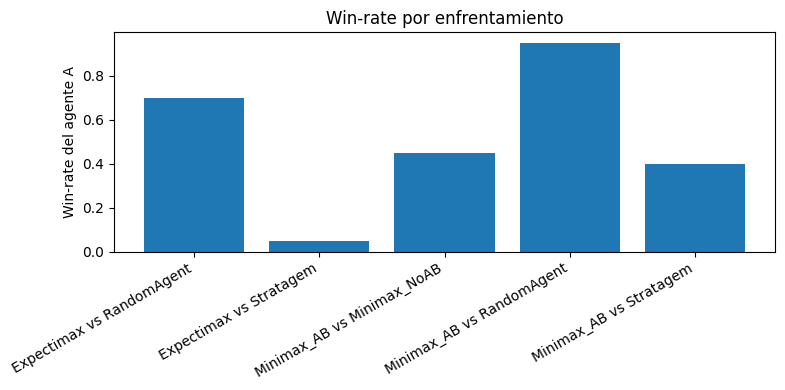

In [33]:
import matplotlib.pyplot as plt

labels = win_rates['agent_a'] + ' vs ' + win_rates['agent_b']
plt.figure(figsize=(8, 4))
plt.bar(labels, win_rates['win_rate_a'])
plt.ylabel('Win-rate del agente A')
plt.xticks(rotation=30, ha='right')
plt.title('Win-rate por enfrentamiento')
plt.tight_layout()
plt.show()

In [34]:
nodes_summary = df.groupby(['agent_a', 'agent_b'])[['nodes_p1', 'nodes_p2']].mean()
nodes_summary

nodes_p1  nodes_p2
agent_a    agent_b                         
Expectimax RandomAgent   52035.50  19039.95
           Stratagem     50937.00  10910.30
Minimax_AB Minimax_NoAB  50180.85  14969.30
           RandomAgent    5989.50   1055.60
           Stratagem      6849.65   1490.00

## Tarea 2 — Experimentación con configuraciones de heurísticas
Comparamos 5 configuraciones de pesos contra `RandomAgent` y `Stratagem` (30 partidas cada una, profundidad 3, Alpha-Beta activado).

In [ ]:
from heuristic_sweep import CONFIGS, DEPTH, N_GAMES
from experiments import run_tournament, win_rate, save_csv
from minimax_agent import MinimaxAgent
from random_agent import RandomAgent
from stratagem import Stratagem

# Reducir N_GAMES para prueba rapida; el CSV oficial usa N_GAMES=30
N = 4
summary = []
for config_name, weights in CONFIGS.items():
    factory = lambda p, w=weights: MinimaxAgent(p, depth=DEPTH, use_alpha_beta=True, weights=w)
    rows_r = run_tournament(factory, lambda p: RandomAgent(p), n_games=N, seed=42, label_a=config_name, label_b='Random')
    rows_s = run_tournament(factory, lambda p: Stratagem(p),   n_games=N, seed=42, label_a=config_name, label_b='Stratagem')
    summary.append({'config': config_name, 'weights': str(weights),
                    'wr_vs_random': win_rate(rows_r, config_name),
                    'wr_vs_stratagem': win_rate(rows_s, config_name)})
    print(f"{config_name}: Random={win_rate(rows_r,config_name):.0%}  Stratagem={win_rate(rows_s,config_name):.0%}")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar resultados completos (N_GAMES=30)
summary_df = pd.read_csv('heuristic_summary.csv')
summary_df

In [ ]:
x = range(len(summary_df))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar([i - width/2 for i in x], summary_df['wr_vs_random'],   width, label='vs RandomAgent')
ax.bar([i + width/2 for i in x], summary_df['wr_vs_stratagem'], width, label='vs Stratagem')
ax.set_xticks(list(x))
ax.set_xticklabels(summary_df['config'], rotation=20, ha='right')
ax.set_ylabel('Win-rate')
ax.set_ylim(0, 1.1)
ax.legend()
ax.set_title('Win-rate por configuración de heurísticas')
plt.tight_layout()
plt.show()